# Chapter 4: Neural Networks -- Crack Detection in Concrete

In this notebook, we build and compare two neural network architectures for **binary image classification**: detecting cracks in concrete surfaces.

For this task, we will cover use: (A) Feedforward Neural Network (FNN) and (B) Convolutional Neural Network (CNN).

---

### Dataset

We use the **"Concrete Crack Images for Classification"** dataset (Özgenel & Sorguç):
- 40,000 images (20,000 cracked, 20,000 uncracked)
- Original resolution: 227×227 pixels, RGB
- We resize to **96×96** for fast training
- We use a **20% subset** (~8,000 images) for this educational example

**Note:** The dataset is downloaded automatically when you run the notebook.

## 1. Imports and Setup

In [2]:
import os
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline

# ── Check PyTorch and GPU availability ───────────────────────────────
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Using device: cuda


## 2. Configuration and Hyperparameters

We define all hyperparameters in one place for easy experimentation.

In [3]:
# ── Image dimensions ────────────────────────────────────────────────
IMG_HEIGHT = 96    # Resize images to 96x96 (fast training)
IMG_WIDTH = 96

# ── Training hyperparameters ────────────────────────────────────────
BATCH_SIZE = 128              # Batch size (tune for your GPU memory)
EPOCHS = 30                   # Maximum training epochs
LEARNING_RATE = 0.0001        # Initial learning rate for Adam
VALIDATION_SPLIT = 0.2        # 80% train, 20% validation
EARLY_STOPPING_PATIENCE = 8   # Stop if val_loss doesn't improve for 8 epochs

# ── Dataset subset ──────────────────────────────────────────────────
# Use 20% of the full dataset for a fast educational run
SUBSET_FRACTION = 0.2
SUBSET_SEED = 42

# ── Reproducibility ─────────────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True

print("Hyperparameters:")
print(f"  Image size:    {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"  Batch size:    {BATCH_SIZE}")
print(f"  Epochs:        {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Val split:     {VALIDATION_SPLIT}")
print(f"  Dataset subset: {SUBSET_FRACTION*100:.0f}%")

Hyperparameters:
  Image size:    96x96
  Batch size:    128
  Epochs:        30
  Learning rate: 0.0001
  Val split:     0.2
  Dataset subset: 20%


## 3. Dataset Setup (Colab-Friendly)

The dataset is **downloaded automatically** via `kagglehub` when you run the cell below (~245 MB). No Kaggle API key is required for this public dataset. Works on **Google Colab** and locally.

The dataset structure:
```
DATA_DIR/
    ├── Positive/   (20,000 crack images)
    └── Negative/   (20,000 no-crack images)
```

In [4]:
# ── Dataset: download via kagglehub (Colab-friendly) ─────────────────────
from pathlib import Path

print("Downloading dataset via kagglehub (~245 MB)...")
try:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub
    _downloaded = kagglehub.dataset_download("arunrk7/surface-crack-detection")
    _path = Path(_downloaded)
    DATA_DIR = None
    for _root, _dirs, _ in os.walk(_path):
        if "Positive" in _dirs and "Negative" in _dirs:
            DATA_DIR = _root
            break
    if DATA_DIR is None:
        DATA_DIR = str(_path)
    print(f"Downloaded to: {DATA_DIR}")
except Exception as e:
    print(f"Download failed: {e}")
    print("Manual setup: download from https://www.kaggle.com/datasets/arunrk7/surface-crack-detection")
    print("Extract so that DATA_DIR contains Positive/ and Negative/ subfolders.")
    raise

# Verify
pos_dir = os.path.join(DATA_DIR, "Positive")
neg_dir = os.path.join(DATA_DIR, "Negative")
if os.path.isdir(pos_dir) and os.path.isdir(neg_dir):
    pos_count = len(os.listdir(pos_dir))
    neg_count = len(os.listdir(neg_dir))
    print(f"Dataset ready: {DATA_DIR}")
    print(f"  Positive (crack):    {pos_count:,} images")
    print(f"  Negative (no crack): {neg_count:,} images")
else:
    raise FileNotFoundError(f"Dataset incomplete at {DATA_DIR}. Need Positive/ and Negative/ folders.")

Using Colab cache for faster access to the 'surface-crack-detection' dataset.
Downloaded to: /kaggle/input/surface-crack-detection
Dataset ready: /kaggle/input/surface-crack-detection
  Positive (crack):    20,000 images
  Negative (no crack): 20,000 images


## 4. Data Preprocessing and Augmentation

### Why Data Augmentation?

Data augmentation artificially increases the diversity of training data by applying random transformations to each image. This helps the model generalize better and reduces overfitting.

We apply the following augmentations **only to training data**:
- **Random rotation** (±20°)
- **Random translation** (±10% shift)
- **Random zoom** (90% to 110%)
- **Random horizontal flip**
- **Brightness jitter** (80% to 120%)

Validation data only gets resized and rescaled (no augmentation), so we evaluate on "clean" images.

In [5]:
# ── Training transforms (with augmentation) ─────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),       # Resize to 96x96
    transforms.RandomAffine(
        degrees=20,              # Random rotation ±20°
        translate=(0.1, 0.1),    # Random shift ±10%
        scale=(0.9, 1.1),        # Random zoom 90-110%
    ),
    transforms.RandomHorizontalFlip(),                 # 50% chance flip
    transforms.ColorJitter(brightness=(0.8, 1.2)),     # Brightness variation
    transforms.ToTensor(),                             # Convert to tensor [0, 1]
])

# ── Validation transforms (no augmentation) ─────────────────────────
val_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),       # Resize to 96x96
    transforms.ToTensor(),                             # Convert to tensor [0, 1]
])

print("Training transforms (with augmentation):")
for t in train_transform.transforms:
    print(f"  - {t}")
print(f"\nValidation transforms (no augmentation):")
for t in val_transform.transforms:
    print(f"  - {t}")

Training transforms (with augmentation):
  - Resize(size=(96, 96), interpolation=bilinear, max_size=None, antialias=True)
  - RandomAffine(degrees=[-20.0, 20.0], translate=(0.1, 0.1), scale=(0.9, 1.1))
  - RandomHorizontalFlip(p=0.5)
  - ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
  - ToTensor()

Validation transforms (no augmentation):
  - Resize(size=(96, 96), interpolation=bilinear, max_size=None, antialias=True)
  - ToTensor()


## 5. Loading the Dataset

We use PyTorch's `ImageFolder` to automatically load images from the Positive/Negative directory structure. Then we:

1. Take a **20% random subset** of the full dataset (for fast training)
2. Split this subset **80/20** into training and validation sets
3. Apply the appropriate transforms to each split
4. Create `DataLoader` objects for batching

In [6]:
class TransformSubset(torch.utils.data.Dataset):
    """
    Wrapper that applies a transform to a Subset dataset.

    PyTorch's random_split returns Subset objects that don't have
    their own transform. This wrapper lets us apply different
    transforms to the training vs validation splits.
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


def load_data():
    """Load and prepare the crack detection dataset."""
    print("Loading dataset...")

    # Load ALL images (ImageFolder assigns labels from folder names)
    full_dataset = datasets.ImageFolder(DATA_DIR)
    total_full = len(full_dataset)
    print(f"  Full dataset: {total_full:,} images")
    print(f"  Classes: {full_dataset.classes}")
    print(f"  Class-to-index: {full_dataset.class_to_idx}")

    # Take a fixed random 20% subset for this educational run
    subset_size = int(total_full * SUBSET_FRACTION)
    indices = torch.randperm(
        total_full,
        generator=torch.Generator().manual_seed(SUBSET_SEED)
    )[:subset_size]
    subset_dataset = Subset(full_dataset, indices.tolist())

    # Split the subset into train (80%) and validation (20%)
    total_size = len(subset_dataset)
    val_size = int(total_size * VALIDATION_SPLIT)
    train_size = total_size - val_size

    train_dataset, val_dataset = random_split(
        subset_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    # Apply transforms
    train_dataset_augmented = TransformSubset(train_dataset, train_transform)
    train_dataset_raw = TransformSubset(train_dataset, val_transform) # For visualization without augmentation
    val_dataset = TransformSubset(val_dataset, val_transform)

    # Create data loaders
    # Note: num_workers=0 on Windows to avoid multiprocessing issues
    worker_count = 0 if os.name == "nt" else 8
    use_persistent_workers = worker_count > 0

    train_loader = DataLoader(
        train_dataset_augmented, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=worker_count, pin_memory=True,
        persistent_workers=use_persistent_workers
    )
    # New loader for raw visualization
    raw_train_loader = DataLoader(
        train_dataset_raw, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=worker_count, pin_memory=True,
        persistent_workers=use_persistent_workers
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=worker_count, pin_memory=True,
        persistent_workers=use_persistent_workers
    )

    print(f"\n  Using {total_size:,} images ({SUBSET_FRACTION*100:.0f}% subset of {total_full:,})")
    print(f"  Training samples:   {train_size:,}")
    print(f"  Validation samples: {val_size:,}")
    print(f"  Batches per epoch:  {len(train_loader)} (train), {len(val_loader)} (val)")

    return train_loader, val_loader, raw_train_loader


# Load the data
train_loader, val_loader, raw_train_loader = load_data()

Loading dataset...
  Full dataset: 40,000 images
  Classes: ['Negative', 'Positive']
  Class-to-index: {'Negative': 0, 'Positive': 1}

  Using 8,000 images (20% subset of 40,000)
  Training samples:   6,400
  Validation samples: 1,600
  Batches per epoch:  50 (train), 13 (val)


### 5.1 Visualizing Sample Images

Let's look at a few examples from the training set to understand what the model sees.

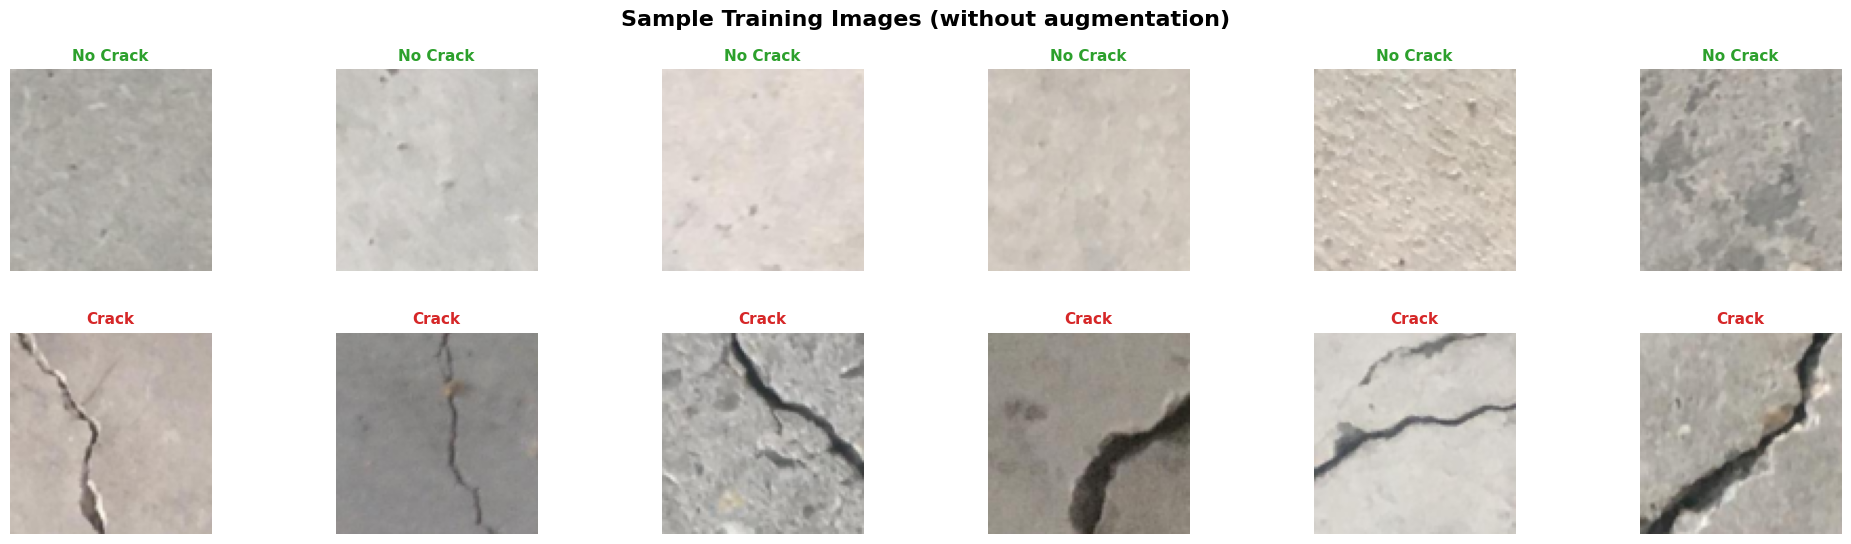

Image tensor shape: torch.Size([3, 96, 96])  (C, H, W)
Pixel value range:  [0.047, 1.000]
Batch class split:  66 no-crack, 62 crack


In [7]:
images_batch, labels_batch = next(iter(raw_train_loader))

class_names = ['No Crack', 'Crack']
title_colors = ['#2ca02c', '#d62728']
n_per_row = 6

no_crack_idx = [i for i, l in enumerate(labels_batch.tolist()) if l == 0][:n_per_row]
crack_idx    = [i for i, l in enumerate(labels_batch.tolist()) if l == 1][:n_per_row]

fig, axes = plt.subplots(2, n_per_row, figsize=(20, 5.5), dpi=100)

for col, idx in enumerate(no_crack_idx):
    img = np.clip(images_batch[idx].permute(1, 2, 0).numpy(), 0, 1)
    axes[0, col].imshow(img)
    axes[0, col].set_title(class_names[0], fontsize=11, color=title_colors[0], fontweight='bold')
    axes[0, col].axis('off')

for col, idx in enumerate(crack_idx):
    img = np.clip(images_batch[idx].permute(1, 2, 0).numpy(), 0, 1)
    axes[1, col].imshow(img)
    axes[1, col].set_title(class_names[1], fontsize=11, color=title_colors[1], fontweight='bold')
    axes[1, col].axis('off')

plt.suptitle('Sample Training Images (without augmentation)', fontsize=16, fontweight='bold')
plt.tight_layout(h_pad=3.0)
plt.show()

print(f"Image tensor shape: {images_batch[0].shape}  (C, H, W)")
print(f"Pixel value range:  [{images_batch.min():.3f}, {images_batch.max():.3f}]")
print(f"Batch class split:  {(labels_batch == 0).sum().item()} no-crack, "
      f"{(labels_batch == 1).sum().item()} crack")

### 5.2 Visualizing Data Augmentation

Below we show each individual augmentation (rotation, flip, brightness, translate/zoom) applied separately, then all of them combined. Two sample images are shown — one from each class.

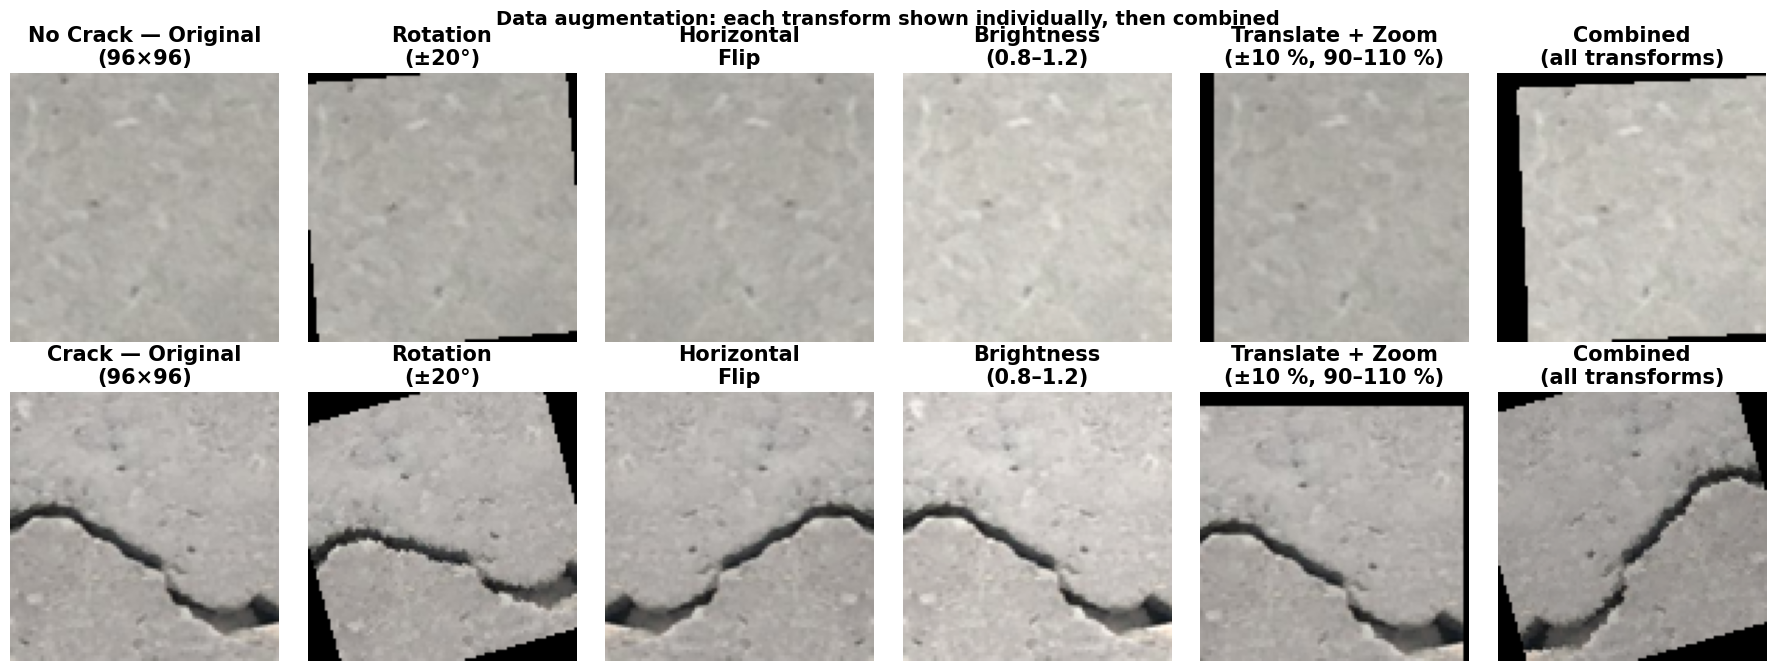

In [8]:
from PIL import Image

# Individual transforms (same parameters as train_transform)
resize_only = transforms.Resize((IMG_HEIGHT, IMG_WIDTH))

augmentations = [
    ("Original\n(96×96)", None),
    ("Rotation\n(±20°)", transforms.Compose([
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.RandomAffine(degrees=20, translate=(0, 0), scale=(1.0, 1.0)),
    ])),
    ("Horizontal\nFlip", transforms.Compose([
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.RandomHorizontalFlip(p=1.0),
    ])),
    ("Brightness\n(0.8–1.2)", transforms.Compose([
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.ColorJitter(brightness=(0.8, 1.2)),
    ])),
    ("Translate + Zoom\n(±10 %, 90–110 %)", transforms.Compose([
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    ])),
    ("Combined\n(all transforms)", transforms.Compose([
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=(0.8, 1.2)),
    ])),
]

# Navigate the nested Subset structure to get to the original ImageFolder
# train_loader.dataset is TransformSubset
# train_loader.dataset.subset is the Subset from random_split (e.g., train_dataset)
# train_loader.dataset.subset.dataset is the Subset created from full_dataset (e.g., subset_dataset)
# train_loader.dataset.subset.dataset.dataset is the original ImageFolder
original_image_folder = train_loader.dataset.subset.dataset.dataset

# Get the indices that map from the `subset_dataset` to `full_dataset`
subset_to_full_map = train_loader.dataset.subset.dataset.indices

# Get the indices that map from the `train_dataset` split to `subset_dataset`
train_split_to_subset_map = train_loader.dataset.subset.indices

class_names = ["No Crack", "Crack"]
n_rows = 2

# Which indices from the *train_dataset split* to show
SAMPLE_INDEX_ROW0 = 0
SAMPLE_INDEX_ROW1 = len(train_split_to_subset_map) // 2

# Map these indices to the full_dataset for PIL image loading
sample_indices_in_full_dataset = [
    subset_to_full_map[train_split_to_subset_map[SAMPLE_INDEX_ROW0]],
    subset_to_full_map[train_split_to_subset_map[SAMPLE_INDEX_ROW1]]
]

n_cols = len(augmentations)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3.4 * n_rows), dpi=100)
for row, idx_in_full in enumerate(sample_indices_in_full_dataset):
    path, label = original_image_folder.samples[idx_in_full]
    img_pil = Image.open(path).convert("RGB")
    for col, (title, tfm) in enumerate(augmentations):
        if tfm is None:
            arr = np.array(resize_only(img_pil)) / 255.0
        else:
            # Apply transforms and convert to numpy for imshow
            # Random transforms require ToTensor to be at the end of the Compose
            # to work with PIL Image before conversion to tensor
            if "RandomAffine" in title or "Horizontal" in title or "Brightness" in title:
                # Re-apply ToTensor after augmentation for display
                tensor = transforms.ToTensor()(tfm(img_pil))
            else:
                # For non-random transforms, directly apply and then ToTensor
                tensor = tfm(img_pil)
                tensor = transforms.ToTensor()(tensor)

            arr = np.clip(tensor.permute(1, 2, 0).numpy(), 0, 1)
        axes[row, col].imshow(arr)
        col_title = f"{class_names[label]} — {title}" if col == 0 else title
        axes[row, col].set_title(col_title, fontsize=15, fontweight="bold")
        axes[row, col].axis("off")

plt.suptitle(
    "Data augmentation: each transform shown individually, then combined",
    fontsize=14, fontweight="bold",
)
plt.tight_layout(h_pad=3.0)
plt.show()

---

# Part A: Feedforward Neural Network (FNN)

---

## 6. FNN Architecture

A **Feedforward Neural Network** (also called a Multilayer Perceptron or Dense Network) treats the image as a **flat vector** of pixel values. It has no knowledge of spatial structure.

### Architecture

```
Input:  96 × 96 × 3 = 27,648 features (flattened image)
   ↓
Dense Layer 1:  22 units, ReLU activation
   ↓
Dense Layer 2:  64 units, ReLU activation
   ↓
Output Layer:   1 unit (logit → sigmoid for probability)
```

### Why these layer sizes?

We intentionally chose layer sizes (22 and 64 units) to make the FNN have approximately **the same number of parameters** as the CNN we'll build later (~610k). This makes the comparison fair: both models have similar "capacity" (number of learnable parameters), but the CNN uses its parameters more efficiently through convolution.

In [9]:
class FNN(nn.Module):
    """
    Feedforward Neural Network for binary image classification.

    The image is flattened into a 1D vector and passed through
    two hidden layers with ReLU activation.

    Architecture:
        Flatten(96x96x3=27648) → Dense(22, ReLU) → Dense(64, ReLU) → Output(1)
    """
    def __init__(self):
        super(FNN, self).__init__()

        # Flatten the 3D image (C×H×W) into a 1D vector
        self.flatten = nn.Flatten()  # 96 * 96 * 3 = 27,648 features

        # Hidden layer 1: 27,648 → 22 units
        self.dense_1 = nn.Linear(IMG_HEIGHT * IMG_WIDTH * 3, 22)

        # Hidden layer 2: 22 → 64 units
        self.dense_2 = nn.Linear(22, 64)

        # Output layer: 64 → 1 unit (logit, not probability)
        self.output_layer = nn.Linear(64, 1)

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        """Forward pass: image → flattened → dense layers → logit."""
        x = self.flatten(x)                    # (batch, 27648)
        x = self.relu(self.dense_1(x))         # (batch, 22)
        x = self.relu(self.dense_2(x))         # (batch, 64)
        x = self.output_layer(x)               # (batch, 1) -- raw logit
        return x


print("FNN class defined.")

FNN class defined.


### 6.1 Counting Parameters

Let's verify the parameter count. For a dense layer with $n_{\text{in}}$ inputs and $n_{\text{out}}$ outputs:

$$\text{Parameters} = n_{\text{in}} \times n_{\text{out}} + n_{\text{out}} \quad (\text{weights} + \text{biases})$$

In [10]:
# Build the model and move to device
fnn_model = FNN().to(device)

# Print architecture
print("FNN Architecture:")
print(fnn_model)

# Count parameters per layer
print("\nParameter breakdown:")
print(f"  {'Layer':<25} {'Shape':<25} {'Parameters':>12}")
print("  " + "-" * 65)
total_params = 0
for name, param in fnn_model.named_parameters():
    count = param.numel()
    total_params += count
    print(f"  {name:<25} {str(list(param.shape)):<25} {count:>12,}")

print("  " + "-" * 65)
print(f"  {'TOTAL':<25} {'':<25} {total_params:>12,}")

# Manual verification
in_features = IMG_HEIGHT * IMG_WIDTH * 3  # 27,648
manual_count = (
    in_features * 22 + 22 +     # dense_1: weights + bias
    22 * 64 + 64 +              # dense_2: weights + bias
    64 * 1 + 1                  # output:  weights + bias
)
print(f"\nManual calculation: {manual_count:,}")
assert total_params == manual_count, "Parameter count mismatch!"
print("✓ Parameter count verified!")

FNN Architecture:
FNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense_1): Linear(in_features=27648, out_features=22, bias=True)
  (dense_2): Linear(in_features=22, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)

Parameter breakdown:
  Layer                     Shape                       Parameters
  -----------------------------------------------------------------
  dense_1.weight            [22, 27648]                    608,256
  dense_1.bias              [22]                                22
  dense_2.weight            [64, 22]                         1,408
  dense_2.bias              [64]                                64
  output_layer.weight       [1, 64]                             64
  output_layer.bias         [1]                                  1
  -----------------------------------------------------------------
  TOTAL                                                    609,815

Manual calculation

## 7. Training Utilities

Before training, we define:
- **Early stopping**: stops training when validation loss stops improving
- **Train/evaluate functions**: handle one epoch of training or evaluation
- **History tracking**: records loss and accuracy for plotting

In [11]:
class EarlyStopping:
    """
    Early stopping to halt training when val_loss stops improving.

    If the validation loss doesn't improve for 'patience' consecutive
    epochs, training is stopped and the best model weights are restored.

    This prevents overfitting: we stop before the model memorizes noise.
    """
    def __init__(self, patience=5, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.best_state = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            # New best! Save the model state.
            self.best_loss = val_loss
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            # No improvement
            self.counter += 1
            if self.verbose:
                print(f'  EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print('  Early stopping triggered. Restoring best weights.')
                model.load_state_dict(self.best_state)


def train_one_epoch(model, dataloader, criterion, optimizer):
    """
    Train the model for one epoch.

    Args:
        model:      the neural network
        dataloader: training data loader
        criterion:  loss function
        optimizer:  optimizer (e.g., Adam)

    Returns:
        epoch_loss, epoch_accuracy
    """
    model.train()  # Set to training mode (enables dropout, etc.)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        # Move data to device (GPU/CPU)
        images = images.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images).squeeze(1)   # (batch,) predictions
        loss = criterion(outputs, labels)

        # Backward pass + update weights
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Track metrics
        running_loss += loss.item() * images.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, dataloader, criterion):
    """
    Evaluate the model on a dataset (no gradient computation).

    Returns:
        epoch_loss, epoch_accuracy
    """
    model.eval()  # Set to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient tracking for efficiency
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.float().to(device, non_blocking=True)

            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


print("Training utilities defined.")

Training utilities defined.


## 8. Training the FNN

We train with:
- **Loss**: `BCEWithLogitsLoss` (Binary Cross-Entropy with built-in sigmoid -- numerically stable)
- **Optimizer**: Adam with learning rate 0.0001 and L2 weight decay (1e-4)
- **LR Scheduler**: ReduceLROnPlateau (halves LR when val_loss plateaus)
- **Early Stopping**: patience of 8 epochs

This should take **2-5 minutes** on a GPU, or **10-15 minutes** on CPU.

In [12]:
print("=" * 60)
print("Training Feedforward Neural Network (FNN)")
print("=" * 60)

# ── Loss function ───────────────────────────────────────────────────
# BCEWithLogitsLoss = sigmoid + binary cross-entropy (numerically stable)
fnn_criterion = nn.BCEWithLogitsLoss()

# ── Optimizer ────────────────────────────────────────────────────────
# Adam with L2 regularization (weight_decay)
fnn_optimizer = optim.Adam(
    fnn_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4  # L2 regularization
)

# ── Learning rate scheduler ──────────────────────────────────────────
# Halve the LR when val_loss plateaus for 5 epochs
fnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    fnn_optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7
)

# ── Early stopping ───────────────────────────────────────────────────
fnn_early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, verbose=True)

# ── Training history ─────────────────────────────────────────────────
fnn_history = {
    'loss': [], 'val_loss': [],
    'accuracy': [], 'val_accuracy': []
}

# ── Training loop ────────────────────────────────────────────────────
print("\nStarting training...\n")
fnn_start = time.perf_counter()

for epoch in range(EPOCHS):
    # Train for one epoch
    train_loss, train_acc = train_one_epoch(
        fnn_model, train_loader, fnn_criterion, fnn_optimizer
    )

    # Validate
    val_loss, val_acc = evaluate(
        fnn_model, val_loader, fnn_criterion
    )

    # Record history
    fnn_history['loss'].append(train_loss)
    fnn_history['val_loss'].append(val_loss)
    fnn_history['accuracy'].append(train_acc)
    fnn_history['val_accuracy'].append(val_acc)

    # Print progress
    current_lr = fnn_optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:2d}/{EPOCHS} - "
          f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - "
          f"lr: {current_lr:.1e}")

    # Step scheduler
    fnn_scheduler.step(val_loss)

    # Check early stopping
    fnn_early_stopping(val_loss, fnn_model)
    if fnn_early_stopping.early_stop:
        break

fnn_elapsed = time.perf_counter() - fnn_start
print(f"\nFNN training completed in {fnn_elapsed / 60:.1f} minutes")
print(f"Final validation accuracy: {fnn_history['val_accuracy'][-1]*100:.2f}%")

Training Feedforward Neural Network (FNN)

Starting training...

Epoch  1/30 - loss: 0.6750 - acc: 0.5691 - val_loss: 0.6362 - val_acc: 0.7819 - lr: 1.0e-04
Epoch  2/30 - loss: 0.6238 - acc: 0.6902 - val_loss: 0.5988 - val_acc: 0.7762 - lr: 1.0e-04
Epoch  3/30 - loss: 0.5997 - acc: 0.7034 - val_loss: 0.5734 - val_acc: 0.8163 - lr: 1.0e-04
Epoch  4/30 - loss: 0.5822 - acc: 0.7541 - val_loss: 0.5525 - val_acc: 0.8306 - lr: 1.0e-04
Epoch  5/30 - loss: 0.5604 - acc: 0.7730 - val_loss: 0.5309 - val_acc: 0.8269 - lr: 1.0e-04
Epoch  6/30 - loss: 0.5489 - acc: 0.7642 - val_loss: 0.5302 - val_acc: 0.8056 - lr: 1.0e-04
Epoch  7/30 - loss: 0.5506 - acc: 0.7462 - val_loss: 0.5011 - val_acc: 0.8387 - lr: 1.0e-04
Epoch  8/30 - loss: 0.5274 - acc: 0.7914 - val_loss: 0.5021 - val_acc: 0.8375 - lr: 1.0e-04
  EarlyStopping counter: 1/8
Epoch  9/30 - loss: 0.5240 - acc: 0.7791 - val_loss: 0.4751 - val_acc: 0.8275 - lr: 1.0e-04
Epoch 10/30 - loss: 0.5050 - acc: 0.7955 - val_loss: 0.4590 - val_acc: 0.8344 

### 8.1 FNN Training Curves

Let's visualize how loss and accuracy evolved during training.

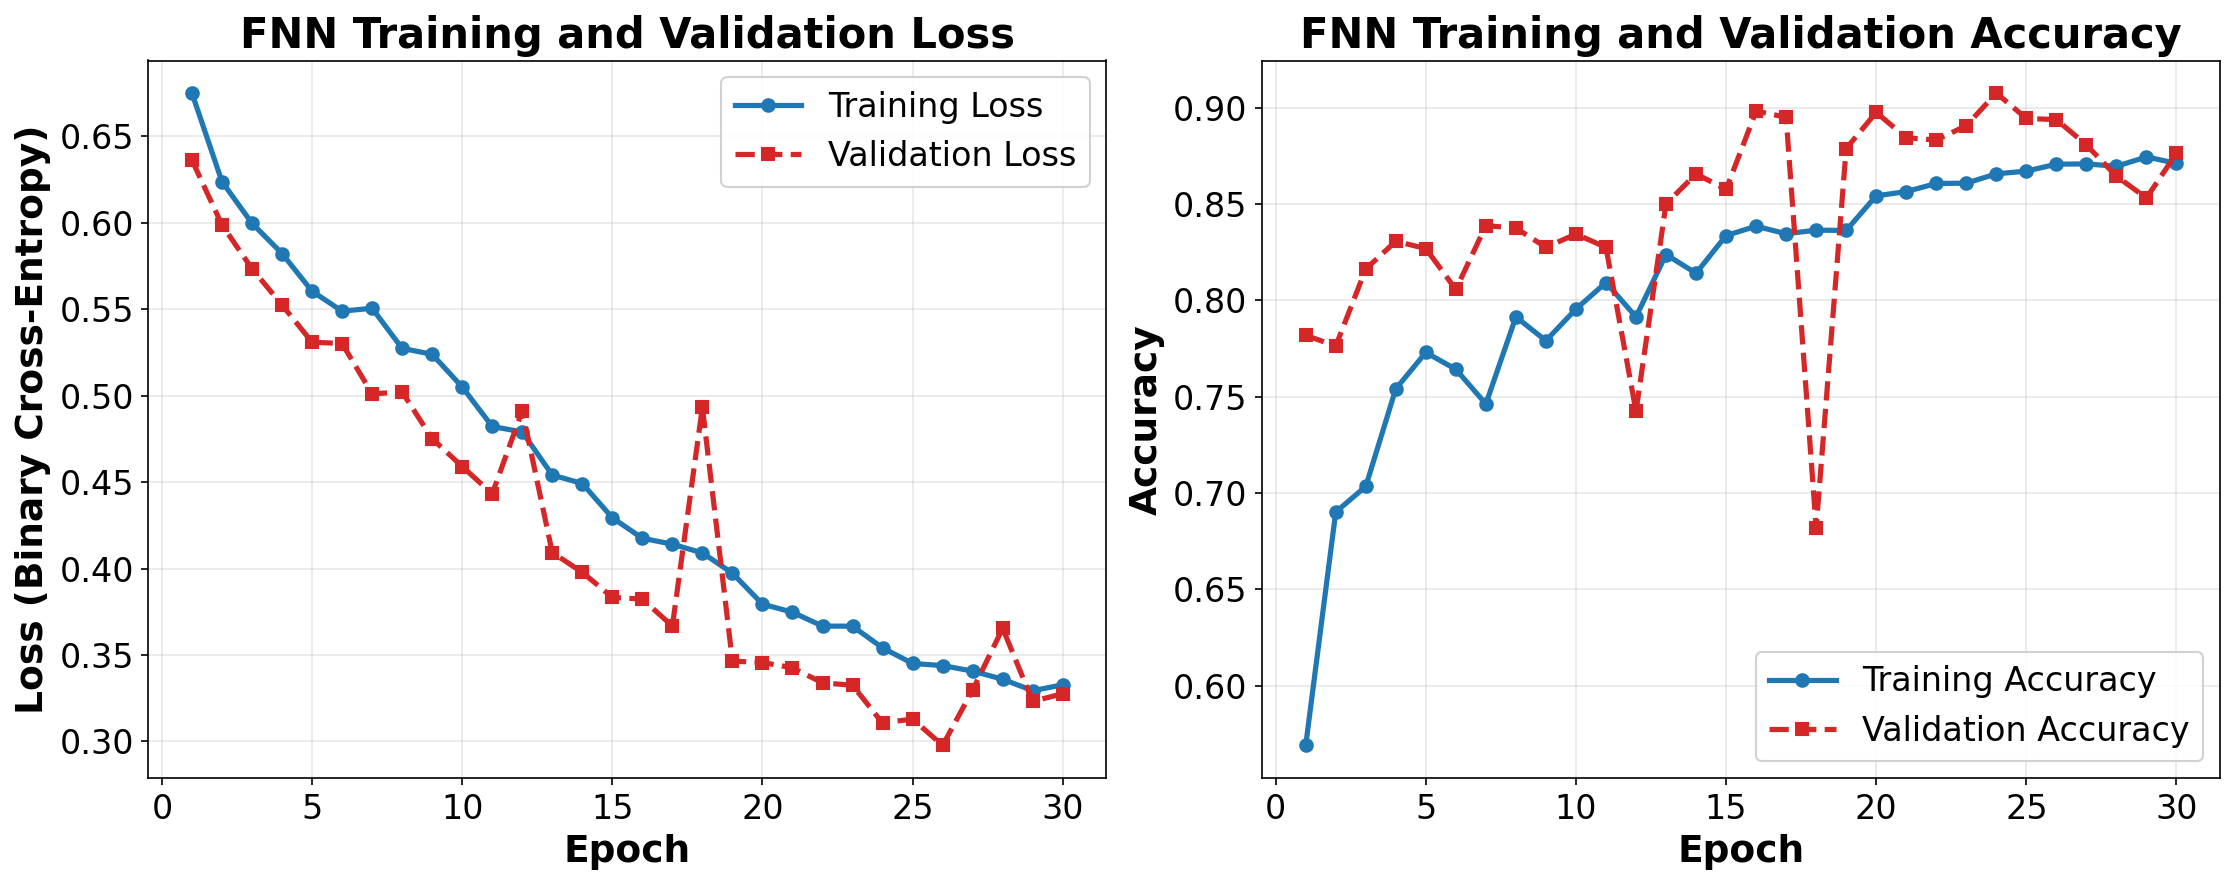

In [13]:
def plot_training_history(history, model_name):
    """
    Plot training and validation loss/accuracy curves.

    These curves help diagnose:
    - Underfitting: both train and val loss are high
    - Overfitting: train loss is low but val loss diverges
    - Good fit: both curves converge and stabilize
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)
    epochs = range(1, len(history['loss']) + 1)

    TRAIN_STYLE = dict(color='#1f77b4', linestyle='-', linewidth=2.5,
                       marker='o', markersize=6)
    VAL_STYLE = dict(color='#d62728', linestyle='--', linewidth=2.5,
                     marker='s', markersize=6)

    # Loss plot
    axes[0].plot(epochs, history['loss'], label='Training Loss', **TRAIN_STYLE)
    axes[0].plot(epochs, history['val_loss'], label='Validation Loss', **VAL_STYLE)
    axes[0].set_xlabel('Epoch', fontsize=18, fontweight='bold')
    axes[0].set_ylabel('Loss (Binary Cross-Entropy)', fontsize=18, fontweight='bold')
    axes[0].set_title(f'{model_name} Training and Validation Loss', fontsize=20, fontweight='bold')
    axes[0].legend(fontsize=16, loc='upper right', framealpha=0.9)
    axes[0].tick_params(labelsize=16)
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(epochs, history['accuracy'], label='Training Accuracy', **TRAIN_STYLE)
    axes[1].plot(epochs, history['val_accuracy'], label='Validation Accuracy', **VAL_STYLE)
    axes[1].set_xlabel('Epoch', fontsize=18, fontweight='bold')
    axes[1].set_ylabel('Accuracy', fontsize=18, fontweight='bold')
    axes[1].set_title(f'{model_name} Training and Validation Accuracy', fontsize=20, fontweight='bold')
    axes[1].legend(fontsize=16, loc='lower right', framealpha=0.9)
    axes[1].tick_params(labelsize=16)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_history(fnn_history, 'FNN')

---

# Part B: Convolutional Neural Network (CNN)

---

## 9. CNN Architecture

A **Convolutional Neural Network** preserves the spatial structure of the image. Instead of flattening the image into a vector, it uses:

1. **Convolutional layers**: slide small filters (3×3) across the image to detect local features (edges, textures, cracks)
2. **Max Pooling**: reduce spatial dimensions by keeping only the maximum value in each 2×2 region
3. **Global Average Pooling (GAP)**: reduce each feature map to a single number by averaging all spatial positions

### Architecture

```
Input: 96 × 96 × 3 (RGB image)
   ↓
Conv Block 1: 48 filters (3×3), ReLU, MaxPool(2×2)  →  48 × 48 × 48
   ↓
Conv Block 2: 96 filters (3×3), ReLU, MaxPool(2×2)  →  24 × 24 × 96
   ↓
Conv Block 3: 160 filters (3×3), ReLU, MaxPool(2×2) →  12 × 12 × 160
   ↓
Conv Block 4: 224 filters (3×3), ReLU, MaxPool(2×2) →   6 ×  6 × 224
   ↓
Global Average Pooling                               →  224
   ↓
Output: 1 unit (logit; sigmoid used for probability)
```

### Why GAP instead of Flatten?

Global Average Pooling (GAP) replaces the traditional "flatten + dense" classifier head. Benefits:
- **Far fewer parameters** (no huge dense layer)
- **More robust** to spatial shifts in the input
- **Less prone to overfitting**

In [14]:
class CNN(nn.Module):
    """
    Compact CNN for binary crack classification.

    Architecture:
        4 convolutional blocks (Conv2d + ReLU + MaxPool2d)
        followed by Global Average Pooling and a single output neuron.

    The CNN detects local spatial features (edges, textures, cracks)
    through its convolutional filters, giving it a major advantage
    over the FNN for image tasks.
    """
    def __init__(self):
        super(CNN, self).__init__()

        # ── Convolutional Block 1 ────────────────────────────────
        # Input: (3, 96, 96) → Output: (48, 48, 48)
        self.conv1 = nn.Conv2d(3, 48, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Convolutional Block 2 ────────────────────────────────
        # Input: (48, 48, 48) → Output: (96, 24, 24)
        self.conv2 = nn.Conv2d(48, 96, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Convolutional Block 3 ────────────────────────────────
        # Input: (96, 24, 24) → Output: (160, 12, 12)
        self.conv3 = nn.Conv2d(96, 160, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Convolutional Block 4 ────────────────────────────────
        # Input: (160, 12, 12) → Output: (224, 6, 6)
        self.conv4 = nn.Conv2d(160, 224, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Classification Head ──────────────────────────────────
        # Global Average Pooling: (224, 6, 6) → (224, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.output_layer = nn.Linear(224, 1)  # Single logit output

        # Activations
        self.relu = nn.ReLU()

    def forward(self, x):
        """Forward pass: image → conv blocks → GAP → raw logit."""
        # Convolutional blocks
        x = self.pool1(self.relu(self.conv1(x)))   # Block 1
        x = self.pool2(self.relu(self.conv2(x)))   # Block 2
        x = self.pool3(self.relu(self.conv3(x)))   # Block 3
        x = self.pool4(self.relu(self.conv4(x)))   # Block 4

        # Classification head
        x = self.gap(x)                             # Global Average Pooling
        x = self.flatten(x)                         # (batch, 224)
        x = self.output_layer(x)                    # (batch, 1) → logit
        return x


print("CNN class defined.")

CNN class defined.


### 9.1 CNN Parameter Count

For a convolutional layer: parameters = $K \times K \times C_{\text{in}} \times C_{\text{out}} + C_{\text{out}}$

where $K$ is the kernel size, $C_{\text{in}}$ is input channels, and $C_{\text{out}}$ is output channels.

In [15]:
# Build the CNN model
cnn_model = CNN().to(device)

# Print architecture
print("CNN Architecture:")
print(cnn_model)

# Count parameters per layer
print("\nParameter breakdown:")
print(f"  {'Layer':<25} {'Shape':<25} {'Parameters':>12}")
print("  " + "-" * 65)
cnn_total_params = 0
for name, param in cnn_model.named_parameters():
    count = param.numel()
    cnn_total_params += count
    print(f"  {name:<25} {str(list(param.shape)):<25} {count:>12,}")

print("  " + "-" * 65)
print(f"  {'TOTAL':<25} {'':<25} {cnn_total_params:>12,}")

# Manual verification
manual_cnn = (
    (3*3*3*48 + 48) +        # conv1
    (3*3*48*96 + 96) +       # conv2
    (3*3*96*160 + 160) +     # conv3
    (3*3*160*224 + 224) +    # conv4
    (224*1 + 1)              # output
)
print(f"\nManual calculation: {manual_cnn:,}")
assert cnn_total_params == manual_cnn, "Parameter count mismatch!"
print("✓ Parameter count verified!")

# Compare with FNN
print(f"\n{'Model':<6} {'Parameters':>12}")
print("-" * 20)
print(f"{'FNN':<6} {total_params:>12,}")
print(f"{'CNN':<6} {cnn_total_params:>12,}")
print(f"\nBoth models have ~{total_params//1000}k parameters -- a fair comparison!")

CNN Architecture:
CNN(
  (conv1): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(96, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(160, 224, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (output_layer): Linear(in_features=224, out_features=1, bias=True)
  (relu): ReLU()
)

Parameter breakdown:
  Layer                     Shape                       Parameters
  ---------------------------------------------------

## 10. Training the CNN

The CNN training setup is similar to the FNN. To keep training consistent and numerically stable:
- Both CNN and FNN use `BCEWithLogitsLoss`
- Both models output raw logits; sigmoid is applied only for probability/thresholding

Same hyperparameters: Adam optimizer, LR=0.0001, weight decay, early stopping.

In [16]:
print("=" * 60)
print("Training Convolutional Neural Network (CNN)")
print("=" * 60)

# ── Loss function ───────────────────────────────────────────────────
# Use logits-based BCE for numerical stability (same as FNN)
cnn_criterion = nn.BCEWithLogitsLoss()

# ── Optimizer ────────────────────────────────────────────────────────
cnn_optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# ── Learning rate scheduler ──────────────────────────────────────────
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7
)

# ── Early stopping ───────────────────────────────────────────────────
cnn_early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, verbose=True)

# ── Training history ─────────────────────────────────────────────────
cnn_history = {
    'loss': [], 'val_loss': [],
    'accuracy': [], 'val_accuracy': []
}

# ── Training loop ────────────────────────────────────────────────────
print("\nStarting training...\n")
cnn_start = time.perf_counter()

for epoch in range(EPOCHS):
    # Train for one epoch
    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer
    )

    # Validate
    val_loss, val_acc = evaluate(
        cnn_model, val_loader, cnn_criterion
    )

    # Record history
    cnn_history['loss'].append(train_loss)
    cnn_history['val_loss'].append(val_loss)
    cnn_history['accuracy'].append(train_acc)
    cnn_history['val_accuracy'].append(val_acc)

    # Print progress
    current_lr = cnn_optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:2d}/{EPOCHS} - "
          f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - "
          f"lr: {current_lr:.1e}")

    # Step scheduler
    cnn_scheduler.step(val_loss)

    # Check early stopping
    cnn_early_stopping(val_loss, cnn_model)
    if cnn_early_stopping.early_stop:
        break

cnn_elapsed = time.perf_counter() - cnn_start
print(f"\nCNN training completed in {cnn_elapsed / 60:.1f} minutes")
print(f"Final validation accuracy: {cnn_history['val_accuracy'][-1]*100:.2f}%")

Training Convolutional Neural Network (CNN)

Starting training...

Epoch  1/30 - loss: 0.6844 - acc: 0.5734 - val_loss: 0.6514 - val_acc: 0.7863 - lr: 1.0e-04
Epoch  2/30 - loss: 0.5846 - acc: 0.7319 - val_loss: 0.5422 - val_acc: 0.6569 - lr: 1.0e-04
Epoch  3/30 - loss: 0.4468 - acc: 0.8186 - val_loss: 0.4916 - val_acc: 0.7119 - lr: 1.0e-04
Epoch  4/30 - loss: 0.2930 - acc: 0.9161 - val_loss: 0.2242 - val_acc: 0.9281 - lr: 1.0e-04
Epoch  5/30 - loss: 0.1990 - acc: 0.9452 - val_loss: 0.1628 - val_acc: 0.9569 - lr: 1.0e-04
Epoch  6/30 - loss: 0.1527 - acc: 0.9575 - val_loss: 0.1141 - val_acc: 0.9613 - lr: 1.0e-04
Epoch  7/30 - loss: 0.1110 - acc: 0.9684 - val_loss: 0.1091 - val_acc: 0.9556 - lr: 1.0e-04
Epoch  8/30 - loss: 0.0920 - acc: 0.9709 - val_loss: 0.0804 - val_acc: 0.9688 - lr: 1.0e-04
Epoch  9/30 - loss: 0.0771 - acc: 0.9752 - val_loss: 0.0731 - val_acc: 0.9738 - lr: 1.0e-04
Epoch 10/30 - loss: 0.0717 - acc: 0.9777 - val_loss: 0.0653 - val_acc: 0.9812 - lr: 1.0e-04
Epoch 11/30 -

### 10.1 CNN Training Curves

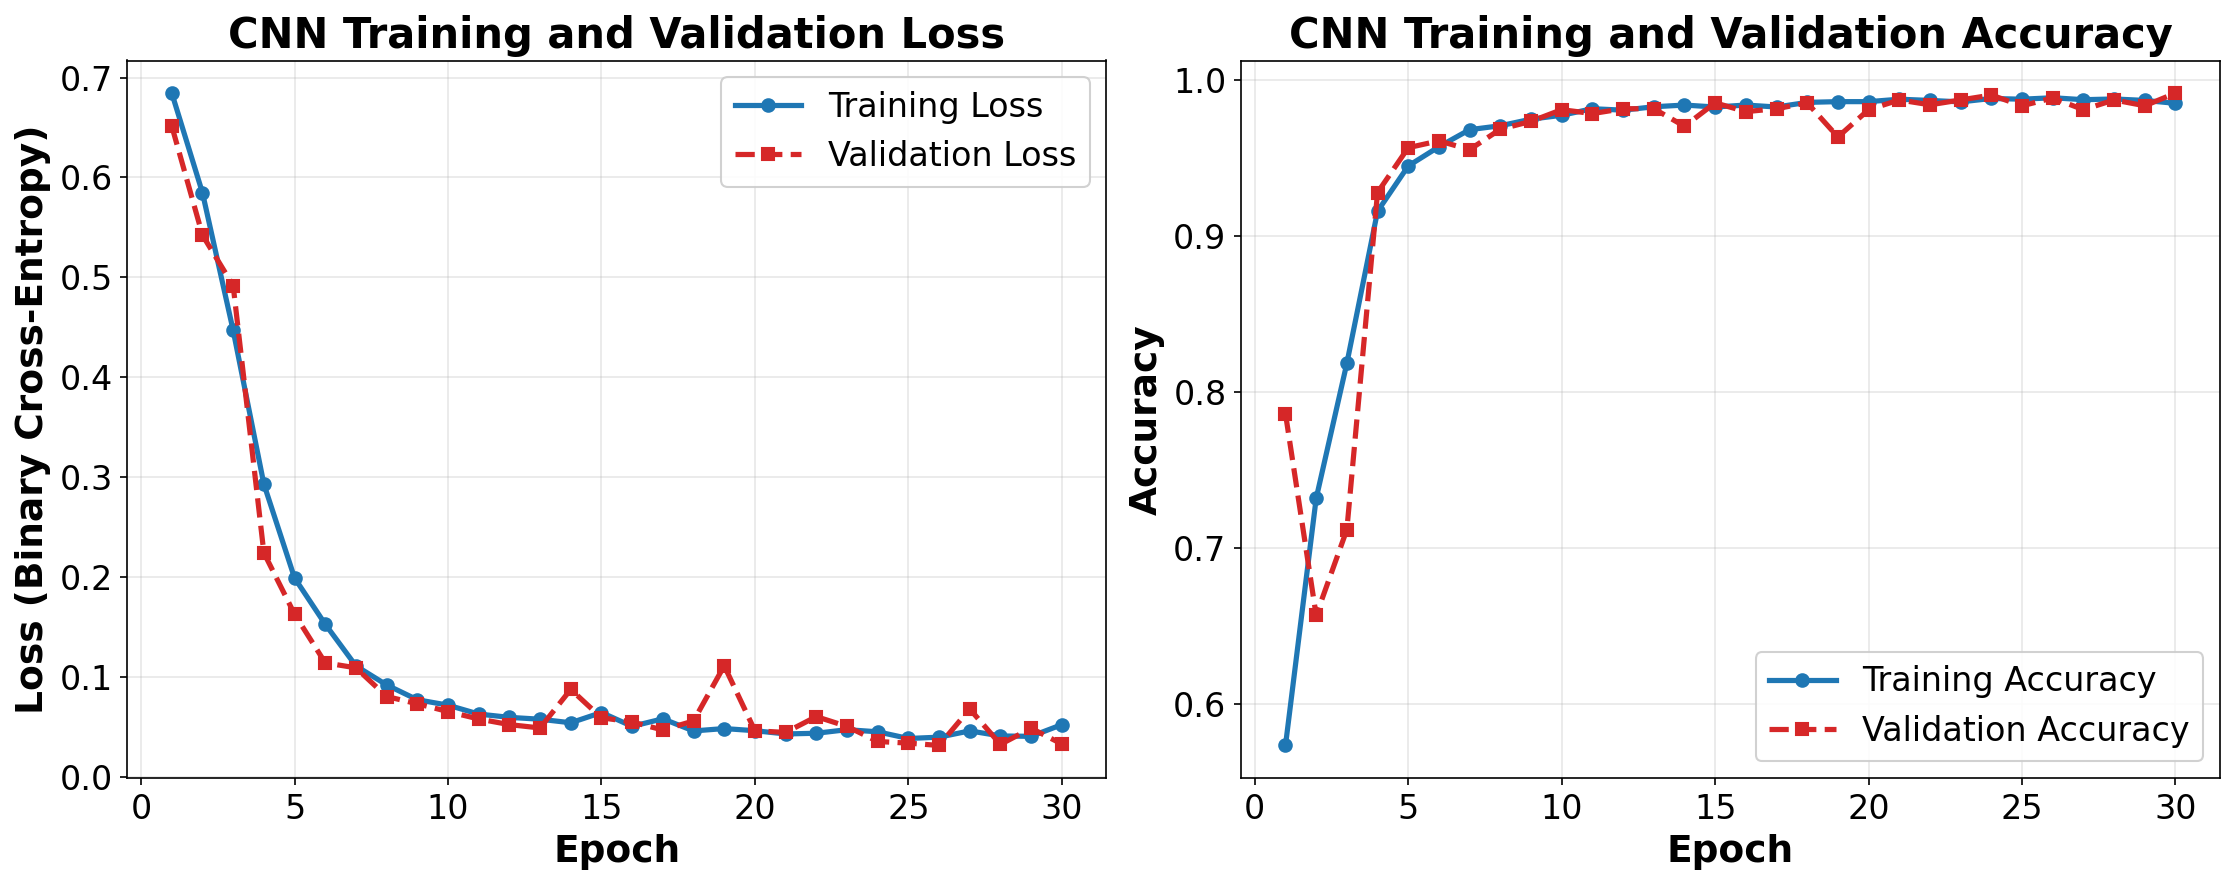

In [17]:
plot_training_history(cnn_history, 'CNN')

---

# Part C: Model Comparison

---

## 11. Side-by-Side Training Curves

Let's compare the FNN and CNN loss curves on the same plot to see how they differ.

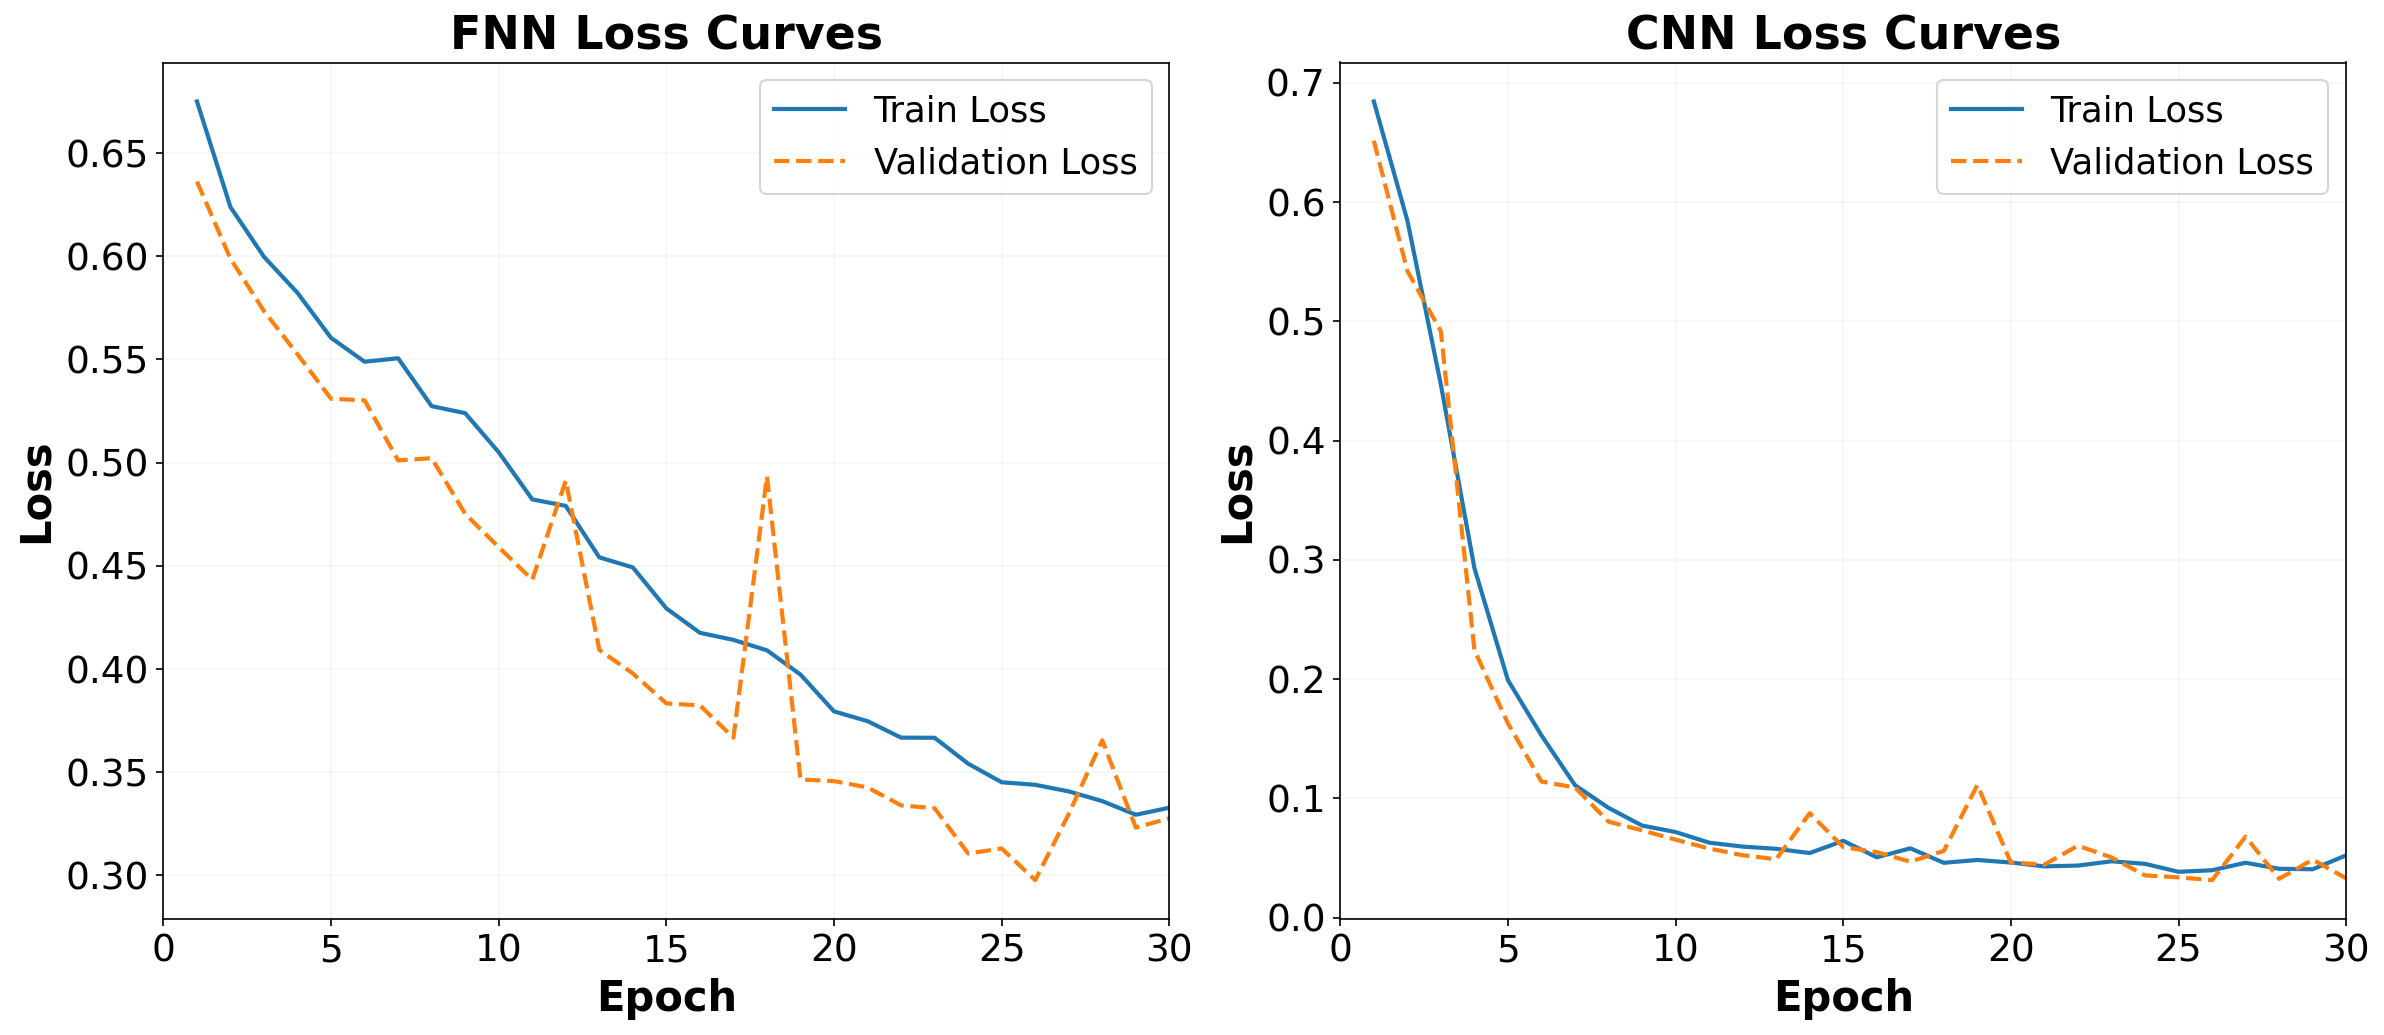

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)
histories = [("FNN", fnn_history), ("CNN", cnn_history)]

for ax, (name, history) in zip(axes, histories):
    epochs = list(range(1, len(history["loss"]) + 1))
    ax.plot(epochs, history["loss"], label="Train Loss", linewidth=2)
    ax.plot(epochs, history["val_loss"], label="Validation Loss",
            linewidth=2, linestyle="--")
    ax.set_title(f"{name} Loss Curves", fontsize=22, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=20, fontweight="bold")
    ax.set_ylabel("Loss", fontsize=20, fontweight="bold")
    ax.set_xlim(0, EPOCHS)
    ax.set_xticks(np.arange(0, EPOCHS + 1, 5))
    ax.grid(alpha=0.1)
    ax.tick_params(labelsize=18)
    ax.legend(fontsize=17)

plt.tight_layout()
plt.show()

## 12. Test Set Evaluation

Now we evaluate both models on the validation set and compute:
- **Accuracy**: fraction of correct predictions
- **Confusion Matrix**: shows true positives, true negatives, false positives, false negatives
- **Classification Report**: precision, recall, F1-score per class

In [19]:
def get_predictions(model, dataloader):
    """
    Get all predictions and true labels from a data loader.

    Returns:
        all_predictions: numpy array of predicted classes (0 or 1)
        all_labels:      numpy array of true labels
        test_loss:       average loss
        test_accuracy:   fraction correct
    """
    model.eval()
    criterion = nn.BCEWithLogitsLoss()

    all_predictions = []
    all_labels = []
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels_float = labels.float().to(device, non_blocking=True)

            outputs = model(images).squeeze(1)

            # Convert logits to probabilities for thresholding
            probs = torch.sigmoid(outputs)
            loss = criterion(outputs, labels_float)

            running_loss += loss.item() * images.size(0)
            predicted = (probs > 0.5).long()
            correct += (predicted == labels.to(device)).sum().item()
            total += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return (
        np.array(all_predictions),
        np.array(all_labels),
        running_loss / total,
        correct / total
    )


# ── Evaluate FNN ─────────────────────────────────────────────────────
print("Evaluating FNN...")
fnn_preds, fnn_labels, fnn_loss, fnn_acc = get_predictions(
    fnn_model, val_loader
)
fnn_cm = confusion_matrix(fnn_labels, fnn_preds)

print(f"\nFNN Test Results:")
print(f"  Accuracy: {fnn_acc*100:.2f}%")
print(f"  Loss:     {fnn_loss:.4f}")
print(f"\nClassification Report:")
print(classification_report(fnn_labels, fnn_preds, target_names=['No Crack', 'Crack']))

# ── Evaluate CNN ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("Evaluating CNN...")
cnn_preds, cnn_labels, cnn_loss, cnn_acc = get_predictions(
    cnn_model, val_loader
)
cnn_cm = confusion_matrix(cnn_labels, cnn_preds)

print(f"\nCNN Test Results:")
print(f"  Accuracy: {cnn_acc*100:.2f}%")
print(f"  Loss:     {cnn_loss:.4f}")
print(f"\nClassification Report:")
print(classification_report(cnn_labels, cnn_preds, target_names=['No Crack', 'Crack']))

Evaluating FNN...

FNN Test Results:
  Accuracy: 87.62%
  Loss:     0.3277

Classification Report:
              precision    recall  f1-score   support

    No Crack       0.87      0.89      0.88       812
       Crack       0.88      0.87      0.87       788

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600


Evaluating CNN...

CNN Test Results:
  Accuracy: 99.19%
  Loss:     0.0328

Classification Report:
              precision    recall  f1-score   support

    No Crack       0.99      0.99      0.99       812
       Crack       0.99      0.99      0.99       788

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600



## 13. Confusion Matrices

A **confusion matrix** shows where each model makes mistakes:
- **True Positive (TP)**: correctly identified crack
- **True Negative (TN)**: correctly identified no crack
- **False Positive (FP)**: predicted crack when there is none
- **False Negative (FN)**: missed a crack

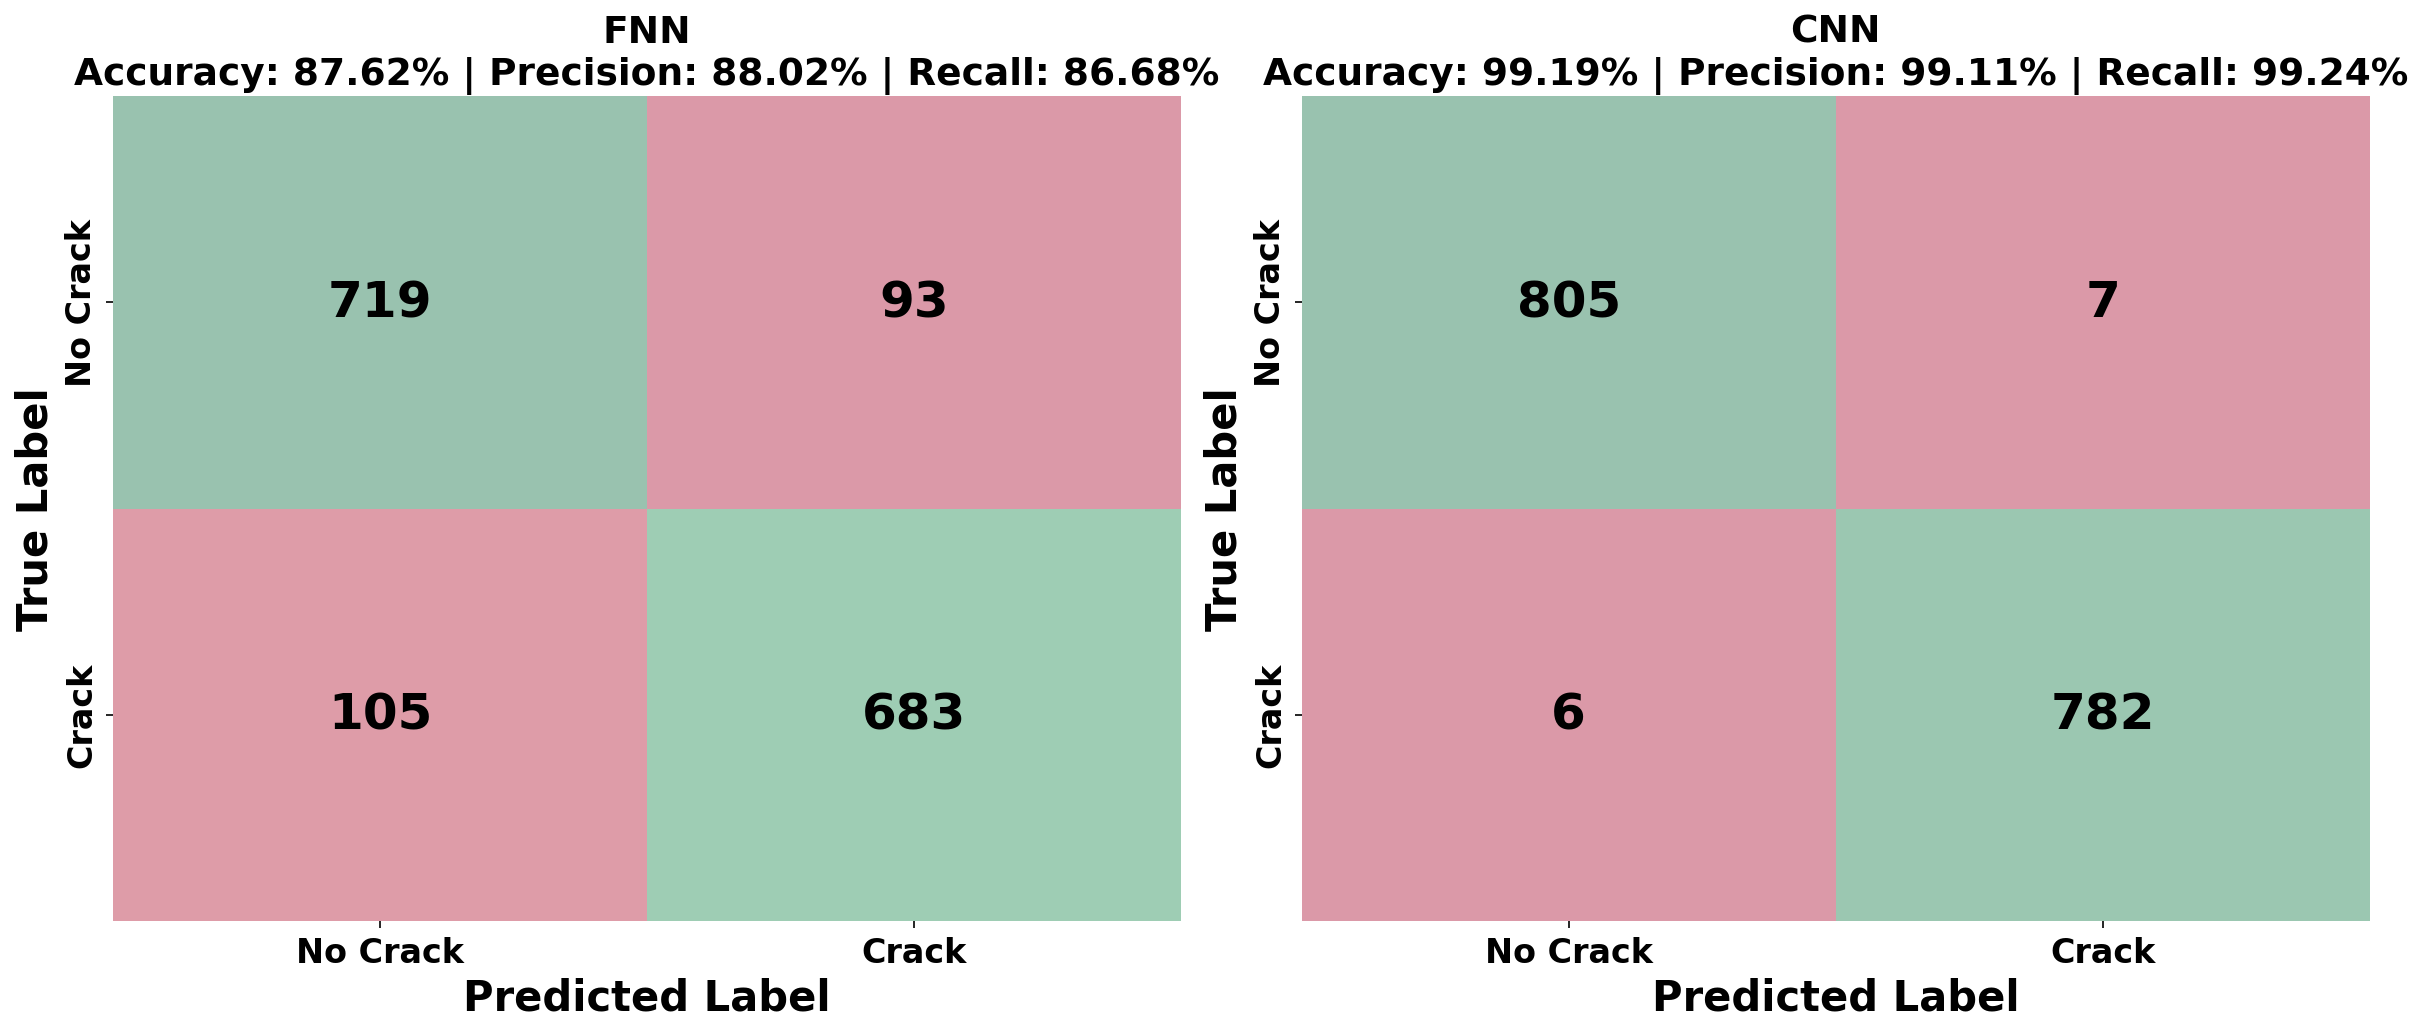

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

results = {
    'FNN': {'cm': fnn_cm, 'accuracy': fnn_acc},
    'CNN': {'cm': cnn_cm, 'accuracy': cnn_acc}
}

for idx, (model_name, res) in enumerate(results.items()):
    cm = res['cm']
    acc = res['accuracy']

    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # Plot confusion matrix as heatmap
    hm = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='RdYlGn',
        ax=axes[idx],
        alpha=0.4,
        cbar=False,
        annot_kws={'size': 24, 'color': 'black', 'fontweight': 'bold'} # Increased font size here
    )

    axes[idx].set_xlabel('Predicted Label', fontsize=20, fontweight='bold', color='black')
    axes[idx].set_ylabel('True Label', fontsize=20, fontweight='bold', color='black')
    axes[idx].set_title(
        f'{model_name}\nAccuracy: {acc*100:.2f}% | Precision: {precision*100:.2f}% | Recall: {recall*100:.2f}%',
        fontsize=18,
        fontweight='bold',
        color='black'
    )

    # Make tick labels bold
    axes[idx].set_xticklabels(['No Crack', 'Crack'], fontsize=16, color='black', fontweight='bold')
    axes[idx].set_yticklabels(['No Crack', 'Crack'], fontsize=16, color='black', fontweight='bold')
    axes[idx].tick_params(axis='both', colors='black')

plt.tight_layout(h_pad=3.0)
plt.show()